In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets

# Adjust image dimensions 
img_height = 150
img_width = 150
img_channels = 3
latent_dim = 64  # Adjust based on your complexity requirements
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        # Adjust kernel sizes and strides as needed for larger images
        self.conv1 = nn.Conv2d(img_channels, 32, kernel_size=5, stride=2, padding=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2)

        # Calculate the output size of conv2
        _, c, h, w = self.conv2(torch.randn(1, img_channels, img_height, img_width)).shape

        self.fc1 = nn.Linear(c * h * w, 128)
        self.fc_mean = nn.Linear(128, latent_dim)
        self.fc_log_var = nn.Linear(128, latent_dim)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.view(x.size(0), -1)  # Flatten the feature maps
        x = torch.relu(self.fc1(x))
        z_mean = self.fc_mean(x)
        z_log_var = self.fc_log_var(x)
        return z_mean, z_log_var

def sampling(z_mean, z_log_var):
    std = torch.exp(0.5 * z_log_var)
    eps = torch.randn_like(std)
    return z_mean + eps * std

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 64 * (img_height // 4) * (img_width // 4))
        # Adjust kernel sizes, strides, and paddings for upsampling to 150x150
        self.deconv1 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.deconv3 = nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, z):
        x = torch.relu(self.fc(z))
        x = x.view(-1, 64, img_height // 4, img_width // 4)
        x = torch.relu(self.deconv1(x))
        x = torch.relu(self.deconv2(x))
        x = torch.sigmoid(self.deconv3(x))
        return x

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = sampling(z_mean, z_log_var)
        reconstructed = self.decoder(z)
        return reconstructed, z_mean, z_log_var

    def vae_loss(self, reconstructed, x, z_mean, z_log_var):
        recon_loss = nn.functional.mse_loss(reconstructed, x, reduction="sum")
        kl_loss = -0.5 * torch.sum(1 + z_log_var - z_mean.pow(2) - z_log_var.exp())
        return recon_loss + kl_loss

    

epochs = 50
batch_size = 32
learning_rate = 0.001


transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)



vae = VAE(latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=learning_rate)


vae.train()
for epoch in range(epochs):
    total_loss = 0
    for x, _ in train_loader:  
        x = x.to(device)
        optimizer.zero_grad()
        
        
        reconstructed, z_mean, z_log_var = vae(x)
        
        
        loss = vae.vae_loss(reconstructed, x, z_mean, z_log_var)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(train_loader.dataset):.4f}")

    
     
vae.eval()
with torch.no_grad():
    sample = next(iter(train_loader))[0][:1].to(device)  
    reconstructed_sample, _, _ = vae(sample)
    print("Original Shape:", sample.shape)
    print("Reconstructed Shape:", reconstructed_sample.shape)

100%|██████████| 170498071/170498071 [00:11<00:00, 14407649.16it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Epoch 1/50, Loss: 112.0611
Epoch 2/50, Loss: 86.2065
Epoch 3/50, Loss: 81.9463
Epoch 4/50, Loss: 80.7941
Epoch 5/50, Loss: 79.9769
Epoch 6/50, Loss: 79.4980
Epoch 7/50, Loss: 79.1052
Epoch 8/50, Loss: 78.7407
Epoch 9/50, Loss: 78.3152
Epoch 10/50, Loss: 78.0737
Epoch 11/50, Loss: 77.8387
Epoch 12/50, Loss: 77.7767
Epoch 13/50, Loss: 77.6250
Epoch 14/50, Loss: 77.4402
Epoch 15/50, Loss: 77.2648
Epoch 16/50, Loss: 77.0458
Epoch 17/50, Loss: 76.9183
Epoch 18/50, Loss: 76.7643
Epoch 19/50, Loss: 76.6980
Epoch 20/50, Loss: 76.5736
Epoch 21/50, Loss: 76.5743
Epoch 22/50, Loss: 76.4648
Epoch 23/50, Loss: 76.4109
Epoch 24/50, Loss: 76.3378
Epoch 25/50, Loss: 76.2307
Epoch 26/50, Loss: 76.2019
Epoch 27/50, Loss: 76.1257
Epoch 28/50, Loss: 76.0622
Epoch 29/50, Loss: 75.9750
Epoch 30/50, Loss: 75.8933
Epoch 31/50, Loss: 75.8683
Epoch 32/50, Loss: 75.8775
Epoch 33/50, Loss: 75.7840
Epoch 34/50, Loss: 75.7413
Epoch 35/50, Loss: 75.7329
Epoch 36/50,

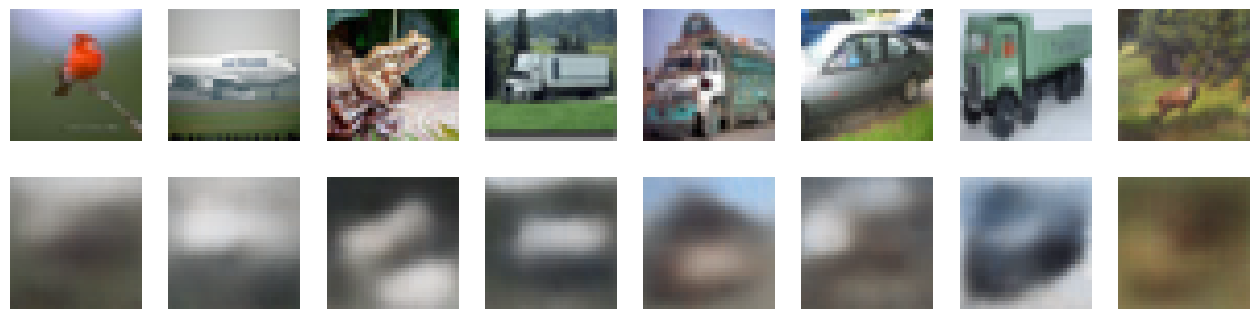

In [2]:
import matplotlib.pyplot as plt

def plot_reconstruction(vae, data_loader):
    vae.eval()
    with torch.no_grad():
        x, _ = next(iter(data_loader))
        x = x.to(device)
        reconstructed, _, _ = vae(x)
        
        
        x = x.cpu()
        reconstructed = reconstructed.cpu()
        
        
        fig, axes = plt.subplots(2, 8, figsize=(16, 4))
        for i in range(8):
            axes[0, i].imshow(x[i].permute(1, 2, 0).squeeze())
            axes[0, i].axis('off')
            axes[1, i].imshow(reconstructed[i].permute(1, 2, 0).squeeze())
            axes[1, i].axis('off')
        plt.show()


        
plot_reconstruction(vae, train_loader)

In [ ]:
epochs = 50
batch_size = 32
learning_rate = 0.001

# Data preprocessing for CIFAR-100
transform = transforms.Compose([
    transforms.Resize((img_height, img_width)),  # Resize to 150x150
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
])

train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

vae = VAE(latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=learning_rate)

vae.train()
for epoch in range(epochs):
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()

        reconstructed, z_mean, z_log_var = vae(x)
        loss = vae.vae_loss(reconstructed, x, z_mean, z_log_var)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(train_loader.dataset):.4f}")


100%|██████████| 169001437/169001437 [00:11<00:00, 14319475.72it/s]


Extracting ./data/cifar-100-python.tar.gz to ./data


RuntimeError: Given groups=1, weight of size [64, 32, 5, 5], expected input[1, 3, 150, 150] to have 32 channels, but got 3 channels instead